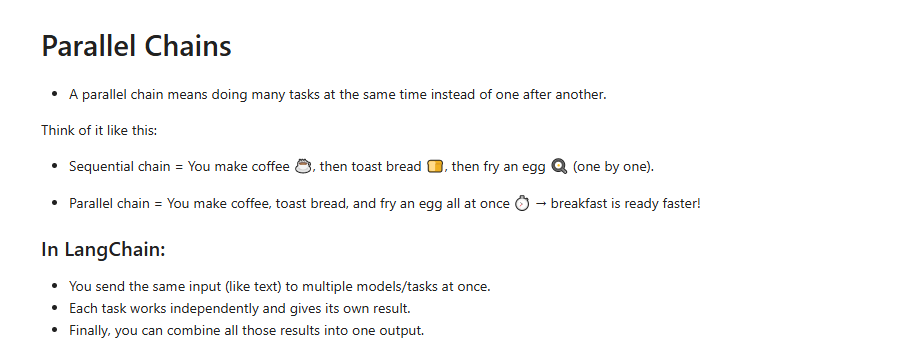

In [ ]:
!pip install langchain-google-genai

In [2]:
#importing libraries
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain.schema.output_parser import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnableParallel
from google.colab import userdata

In [3]:
#getting api key
api_key = userdata.get("GOOGLE_API_KEY")

In [4]:
#selecting the model
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.0-flash",
    google_api_key = api_key
)

In [5]:
#providing message template
messages = [
    ("system", "You are a movie critic."),
    ("human", "Provide a brief summary of the movie {movie_name}."),
]

#converting the message into a prompt template
summary_template = ChatPromptTemplate.from_messages(messages)

In [6]:
#function to analyze the plot
def analyze_plot(plot):
  plot_template = ChatPromptTemplate.from_messages(
      [
          ("system", "You are a movie critic."),
          ("human", "Analyze the plot: {plot}. What are its strengths and weaknesses?"),
      ]
  )
  #fill the template with actual plot values
  return plot_template.format_prompt(plot = plot)

#function to analyze a character in a movie
def analyze_characters(characters):
  characters_template = ChatPromptTemplate.from_messages(
      [
            ("system", "You are a movie critic."),
           ("human", "Analyze the characters: {characters}. What are their strengths and weaknenesses?")
      ]
  )

  #fill the templates with character names
  return characters_template.format_prompt(characters= characters)

In [7]:
#function to combine both plot and character into one verdict
def combine(analyze_plot, analyze_characters):
  return f"Plot analysis:\n{analyze_plot}\n\nCharacter Analysis:\n{analyze_characters}"

In [8]:
#Branch1 analyze the plot
plot_branch = (RunnableLambda(lambda x: analyze_plot(x)) | llm | StrOutputParser())

#Branch2 analyze the character
characters_branch = (RunnableLambda(lambda x: analyze_characters(x)) | llm | StrOutputParser())

In [13]:
#making a chain
chain = (summary_template | llm | StrOutputParser() |
#running tasks in parallel (faaster)
RunnableParallel(branches = {"plot":plot_branch, "characters":characters_branch}) |
#combine both results
RunnableLambda(lambda x: combine(x["branches"]["plot"], x["branches"]["characters"]))
)
#filling the values with real values
response = chain.invoke({
    "movie_name": "Harry Potter"
})

#getting response
print(response)

Plot analysis:
Alright, let's delve into the cauldron of the Harry Potter plot. Overall, it's a remarkably strong narrative engine, but like any magical creation, it has its imperfections.

**Strengths:**

*   **Compelling Protagonist:** Harry is a classic underdog. He's relatable despite his extraordinary circumstances because he's fundamentally decent, flawed, and constantly striving to do the right thing. His journey from a neglected orphan to a confident, albeit reluctant, leader is incredibly engaging.
*   **Well-Developed World-Building:** Hogwarts and the wider wizarding world are richly detailed and imaginative. The intricate rules of magic, the distinct houses, the fantastical creatures, and the historical context all contribute to a believable and immersive experience. This level of detail allows for a deep connection with the story.
*   **Strong Central Conflict:** The battle between good and evil, embodied by Harry and Voldemort, provides a clear and compelling through-line